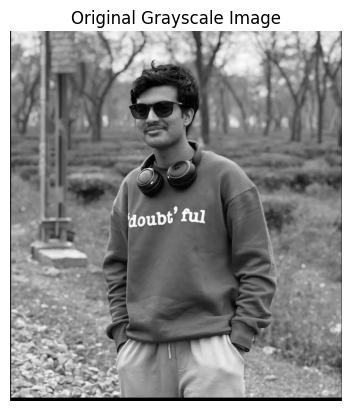

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("/Users/abhinavkshitij/Desktop/Screenshot 2026-08-21 at 9.31.24 PM.png")

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

In [4]:
sobel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

In [5]:
def convolution(image, kernel):

    h, w = image.shape
    kh, kw = kernel.shape

    pad_h = kh // 2
    pad_w = kw // 2

    padded = np.pad(
        image,
        ((pad_h, pad_h), (pad_w, pad_w)),
        mode="constant"
    )

    output = np.zeros_like(image, dtype=np.float32)

    for i in range(h):
        for j in range(w):

            region = padded[
                i:i+kh,
                j:j+kw
            ]

            output[i, j] = np.sum(region * kernel)

    return output

In [6]:
edge_x = convolution(gray, sobel_x)
edge_y = convolution(gray, sobel_y)

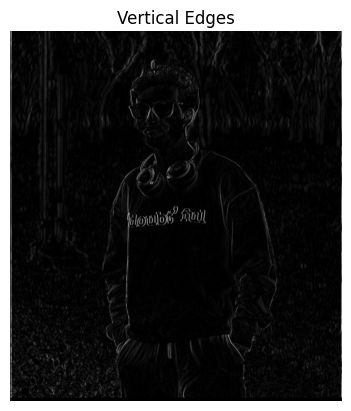

In [7]:
plt.imshow(np.abs(edge_x), cmap="gray")
plt.title("Vertical Edges")
plt.axis("off")
plt.show()

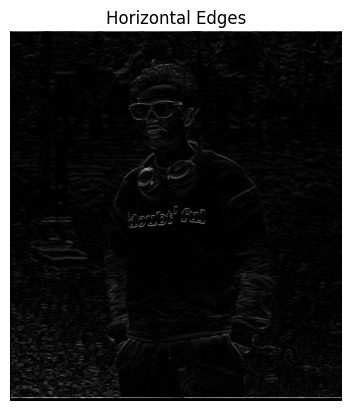

In [8]:
plt.imshow(np.abs(edge_y), cmap="gray")
plt.title("Horizontal Edges")
plt.axis("off")
plt.show()

In [9]:
magnitude = np.sqrt(edge_x**2 + edge_y**2)

In [10]:
magnitude = magnitude / magnitude.max() * 255
magnitude = magnitude.astype(np.uint8)

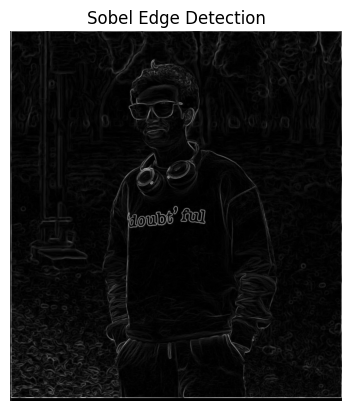

In [11]:
plt.imshow(magnitude, cmap="gray")
plt.title("Sobel Edge Detection")
plt.axis("off")
plt.show()